In [ ]:
#Dataset link: https://drive.google.com/file/d/1stLh4iwPS_szCE_bkt4w2Vy6UCybKO0q/view?usp=sharing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('/content/Covid_19_Clean_Complete (2).csv')
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [ ]:
df.rename(columns={'Province/State':'state','Country/Region':'Country'},inplace=True)

In [ ]:
df['Date'].value_counts()

,count
Date,
2020-01-22,261
2020-01-23,261
2020-01-24,261
2020-01-25,261
2020-01-26,261
...,...
2020-07-23,261
2020-07-24,261
2020-07-25,261


In [ ]:
df['Date'].max()

'2020-07-27'

In [ ]:
top_data=df[df['Date']=='2020-07-27']

In [ ]:
top_data.head()

,state,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48807,NaN,Afghanistan,33.93911,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean
48808,NaN,Albania,41.15330,20.168300,2020-07-27,4880,144,2745,1991,Europe
48809,NaN,Algeria,28.03390,1.659600,2020-07-27,27973,1163,18837,7973,Africa
48810,NaN,Andorra,42.50630,1.521800,2020-07-27,907,52,803,52,Europe
48811,NaN,Angola,-11.20270,17.873900,2020-07-27,950,41,242,667,Africa


In [ ]:
top_data.groupby(['Country'])[['Confirmed','Recovered','Active','Deaths']].sum().reset_index()

,Country,Confirmed,Recovered,Active,Deaths
0,Afghanistan,36263,25198,9796,1269
1,Albania,4880,2745,1991,144
2,Algeria,27973,18837,7973,1163
3,Andorra,907,803,52,52
4,Angola,950,242,667,41
...,...,...,...,...,...
182,West Bank and Gaza,10621,3752,6791,78
183,Western Sahara,10,8,1,1
184,Yemen,1691,833,375,483
185,Zambia,4552,2815,1597,140


In [ ]:
confirmed_cases=df.groupby(['Date'])[['Confirmed']].sum().reset_index()

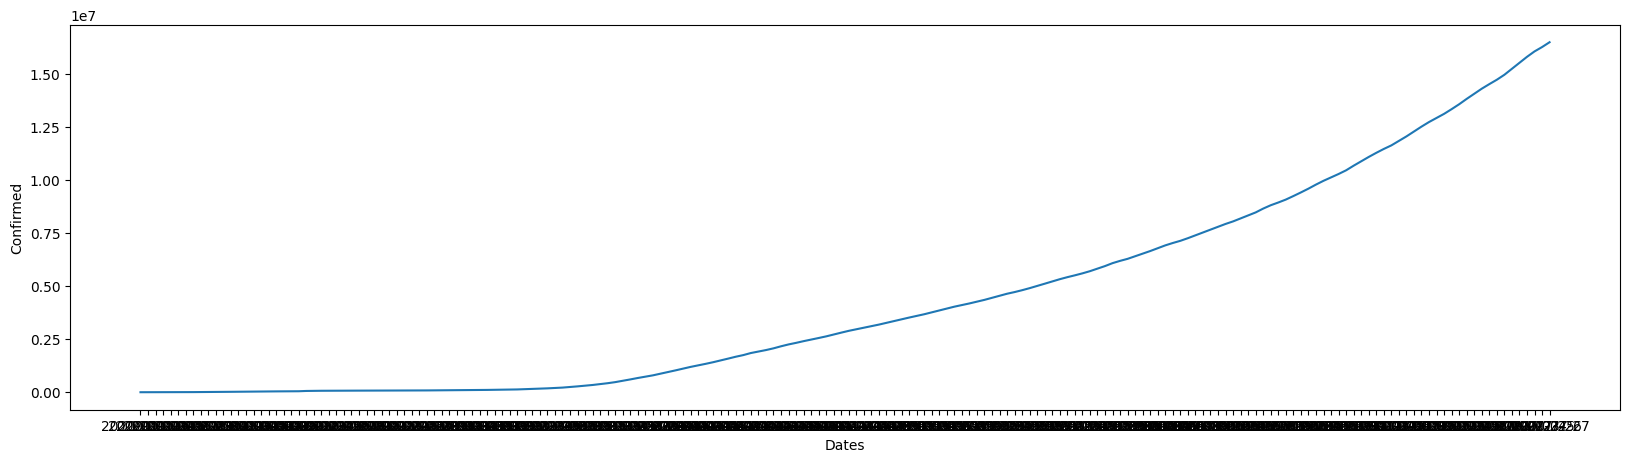

In [ ]:
plt.figure(figsize=(20,5))
sns.lineplot(data=confirmed_cases,x='Date',y='Confirmed')
plt.xlabel("Dates")
plt.ylabel("Confirmed")
plt.show()

In [ ]:
Death_cases = df.groupby('Date')['Deaths'].sum().reset_index()
Death_cases

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


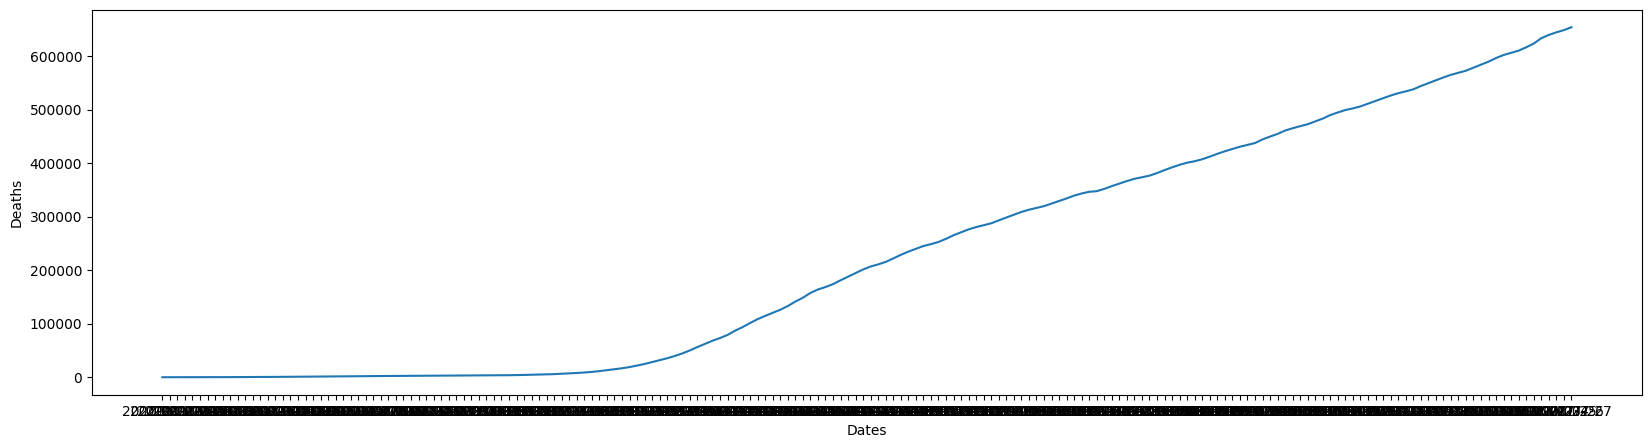

In [ ]:
plt.figure(figsize=(20,5))
sns.lineplot(data=Death_cases,x='Date',y='Deaths')
plt.xlabel("Dates")
plt.ylabel("Deaths")
plt.show()

In [ ]:
Recovered_cases=df.groupby('Date')['Recovered'].sum().reset_index()
Recovered_cases

,Date,Recovered
0,2020-01-22,28
1,2020-01-23,30
2,2020-01-24,36
3,2020-01-25,39
4,2020-01-26,52
...,...,...
183,2020-07-23,8710969
184,2020-07-24,8939705
185,2020-07-25,9158743
186,2020-07-26,9293464


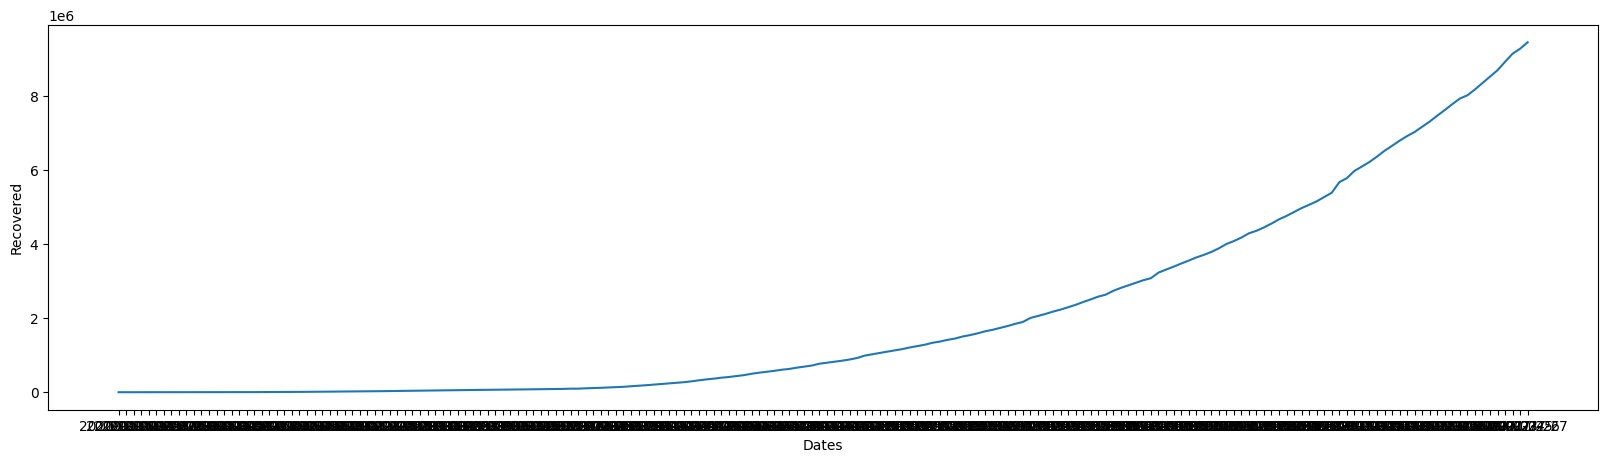

In [ ]:
plt.figure(figsize=(20,5))
sns.lineplot(data=Recovered_cases,x='Date',y='Recovered')
plt.xlabel("Dates")
plt.ylabel("Recovered")
plt.show()

In [ ]:
Active_cases=df.groupby('Date')['Active'].sum().reset_index()
Active_cases

,Date,Active
0,2020-01-22,510
1,2020-01-23,606
2,2020-01-24,879
3,2020-01-25,1353
4,2020-01-26,2010
...,...,...
183,2020-07-23,6166006
184,2020-07-24,6212290
185,2020-07-25,6243930
186,2020-07-26,6309711


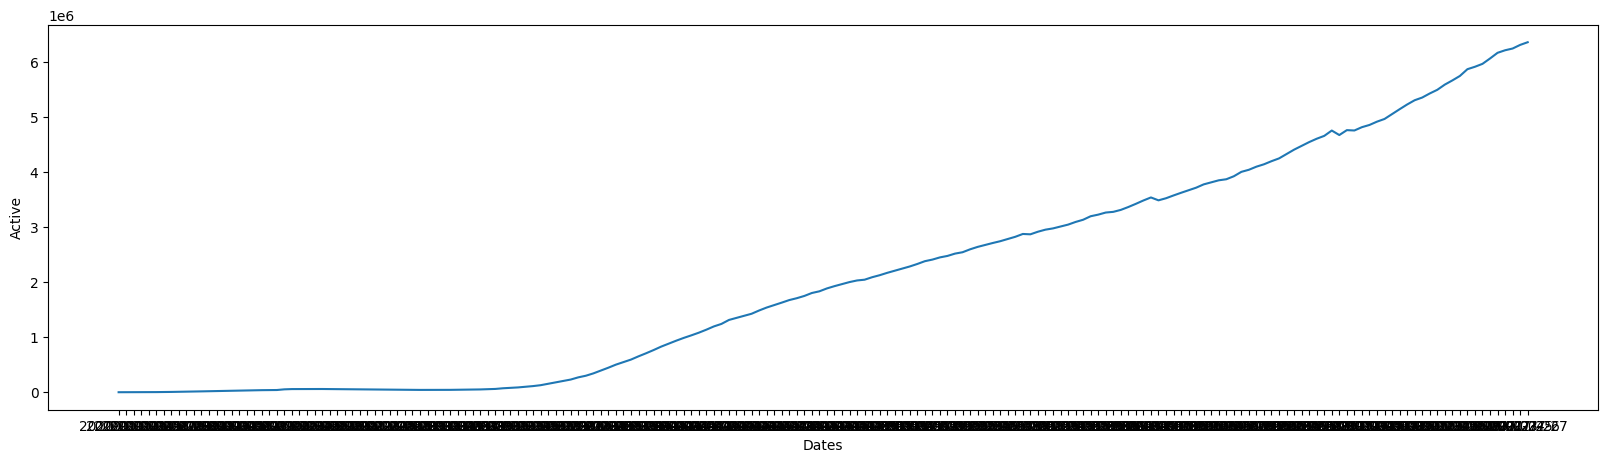

In [ ]:
plt.figure(figsize=(20,5))
sns.lineplot(data=Active_cases,x='Date',y='Active')
plt.xlabel("Dates")
plt.ylabel("Active")
plt.show()

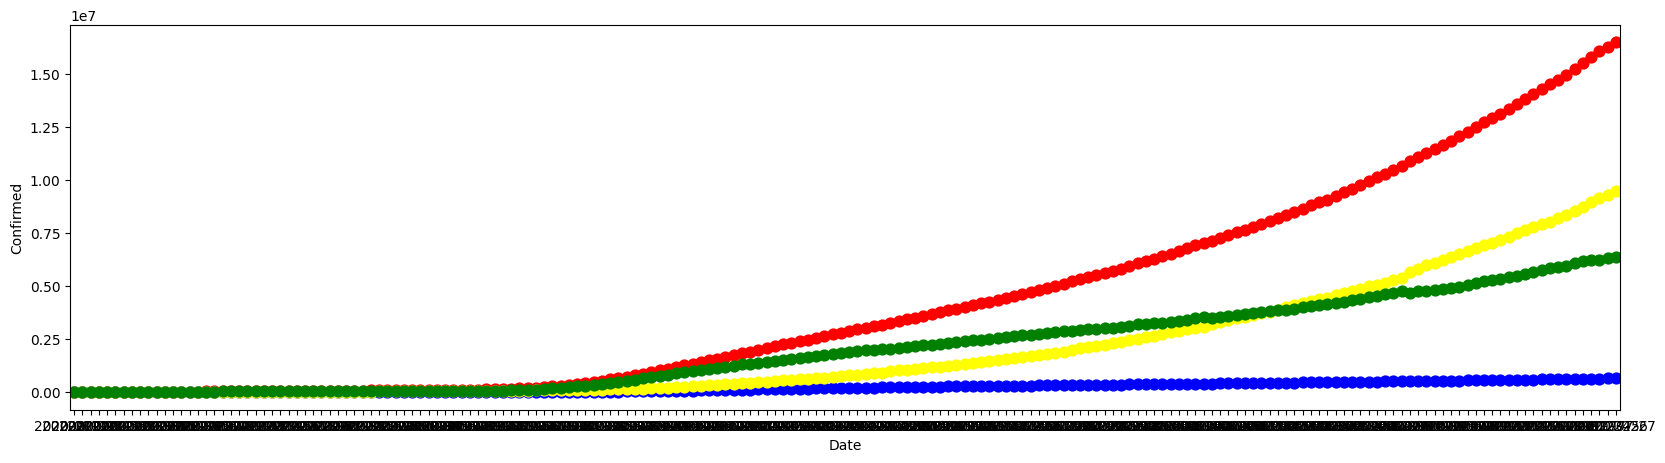

In [ ]:
plt.figure(figsize=(20,5))
sns.pointplot(data=confirmed_cases,x='Date',y='Confirmed',color='Red')
sns.pointplot(data=Death_cases,x='Date',y='Deaths',color='Blue')
sns.pointplot(data=Recovered_cases,x='Date',y='Recovered',color='Yellow')
sns.pointplot(data=Active_cases,x='Date',y='Active',color='Green')
plt.show()

In [ ]:
#Top 3 affected country
#1. US
#2. China
#3. India

In [ ]:
Us=df[df['Country']=='US']
Us

,state,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
223,NaN,US,40.0,-100.0,2020-01-22,1,0,0,1,Americas
484,NaN,US,40.0,-100.0,2020-01-23,1,0,0,1,Americas
745,NaN,US,40.0,-100.0,2020-01-24,2,0,0,2,Americas
1006,NaN,US,40.0,-100.0,2020-01-25,2,0,0,2,Americas
1267,NaN,US,40.0,-100.0,2020-01-26,5,0,0,5,Americas
...,...,...,...,...,...,...,...,...,...,...
47986,NaN,US,40.0,-100.0,2020-07-23,4038816,144430,1233269,2661117,Americas
48247,NaN,US,40.0,-100.0,2020-07-24,4112531,145560,1261624,2705347,Americas
48508,NaN,US,40.0,-100.0,2020-07-25,4178970,146465,1279414,2753091,Americas
48769,NaN,US,40.0,-100.0,2020-07-26,4233923,146935,1297863,2789125,Americas


In [ ]:
Us=Us.groupby(['Date'])[['Confirmed','Active','Recovered','Deaths']].sum().reset_index()
Us

,Date,Confirmed,Active,Recovered,Deaths
0,2020-01-22,1,1,0,0
1,2020-01-23,1,1,0,0
2,2020-01-24,2,2,0,0
3,2020-01-25,2,2,0,0
4,2020-01-26,5,5,0,0
...,...,...,...,...,...
183,2020-07-23,4038816,2661117,1233269,144430
184,2020-07-24,4112531,2705347,1261624,145560
185,2020-07-25,4178970,2753091,1279414,146465
186,2020-07-26,4233923,2789125,1297863,146935


In [ ]:
China=df[df['Country']=='China']
China

,state,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48,Anhui,China,31.8257,117.2264,2020-01-22,1,0,0,1,Western Pacific
49,Beijing,China,40.1824,116.4142,2020-01-22,14,0,0,14,Western Pacific
50,Chongqing,China,30.0572,107.8740,2020-01-22,6,0,0,6,Western Pacific
51,Fujian,China,26.0789,117.9874,2020-01-22,1,0,0,1,Western Pacific
52,Gansu,China,35.7518,104.2861,2020-01-22,0,0,0,0,Western Pacific
...,...,...,...,...,...,...,...,...,...,...
48883,Tianjin,China,39.3054,117.3230,2020-07-27,204,3,195,6,Western Pacific
48884,Tibet,China,31.6927,88.0924,2020-07-27,1,0,1,0,Western Pacific
48885,Xinjiang,China,41.1129,85.2401,2020-07-27,311,3,73,235,Western Pacific
48886,Yunnan,China,24.9740,101.4870,2020-07-27,190,2,186,2,Western Pacific


In [ ]:
China=China.groupby(['Date'])[['Recovered','Deaths','Active','Confirmed']].sum().reset_index()
China

,Date,Recovered,Deaths,Active,Confirmed
0,2020-01-22,28,17,503,548
1,2020-01-23,30,18,595,643
2,2020-01-24,36,26,858,920
3,2020-01-25,39,42,1325,1406
4,2020-01-26,49,56,1970,2075
...,...,...,...,...,...
183,2020-07-23,78701,4649,2695,86045
184,2020-07-24,78745,4650,2807,86202
185,2020-07-25,78813,4652,2916,86381
186,2020-07-26,78862,4652,3056,86570


In [ ]:
India=df[df['Country']=='India']
India

,state,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
129,NaN,India,20.593684,78.96288,2020-01-22,0,0,0,0,South-East Asia
390,NaN,India,20.593684,78.96288,2020-01-23,0,0,0,0,South-East Asia
651,NaN,India,20.593684,78.96288,2020-01-24,0,0,0,0,South-East Asia
912,NaN,India,20.593684,78.96288,2020-01-25,0,0,0,0,South-East Asia
1173,NaN,India,20.593684,78.96288,2020-01-26,0,0,0,0,South-East Asia
...,...,...,...,...,...,...,...,...,...,...
47892,NaN,India,20.593684,78.96288,2020-07-23,1288108,30601,817209,440298,South-East Asia
48153,NaN,India,20.593684,78.96288,2020-07-24,1337024,31358,849432,456234,South-East Asia
48414,NaN,India,20.593684,78.96288,2020-07-25,1385635,32060,885573,468002,South-East Asia
48675,NaN,India,20.593684,78.96288,2020-07-26,1435616,32771,917568,485277,South-East Asia


In [ ]:
India=India.groupby(['Date'])[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
India

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,1288108,30601,817209,440298
184,2020-07-24,1337024,31358,849432,456234
185,2020-07-25,1385635,32060,885573,468002
186,2020-07-26,1435616,32771,917568,485277


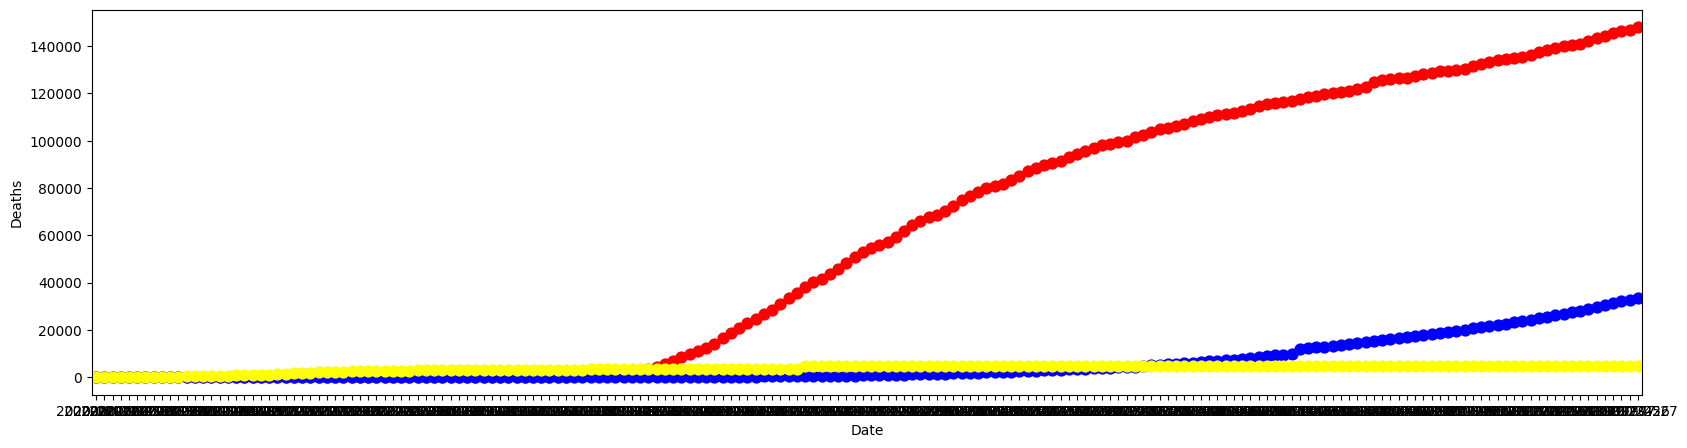

In [ ]:
plt.figure(figsize=(20,5))
sns.pointplot(data=Us,x='Date',y='Deaths',color='Red')
sns.pointplot(data=India,x='Date',y='Deaths',color='Blue')
sns.pointplot(data=China,x='Date',y='Deaths',color='Yellow')
plt.show()

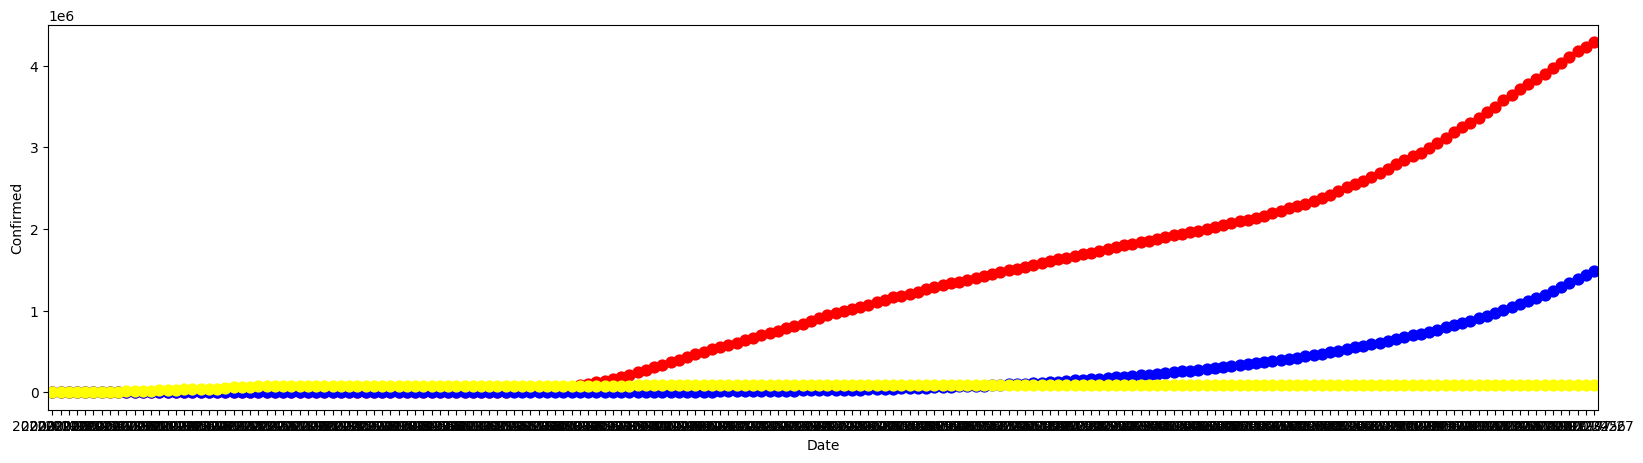

In [ ]:
plt.figure(figsize=(20,5))
sns.pointplot(data=Us,x='Date',y='Confirmed',color='Red')
sns.pointplot(data=India,x='Date',y='Confirmed',color='Blue')
sns.pointplot(data=China,x='Date',y='Confirmed',color='Yellow')
plt.show()

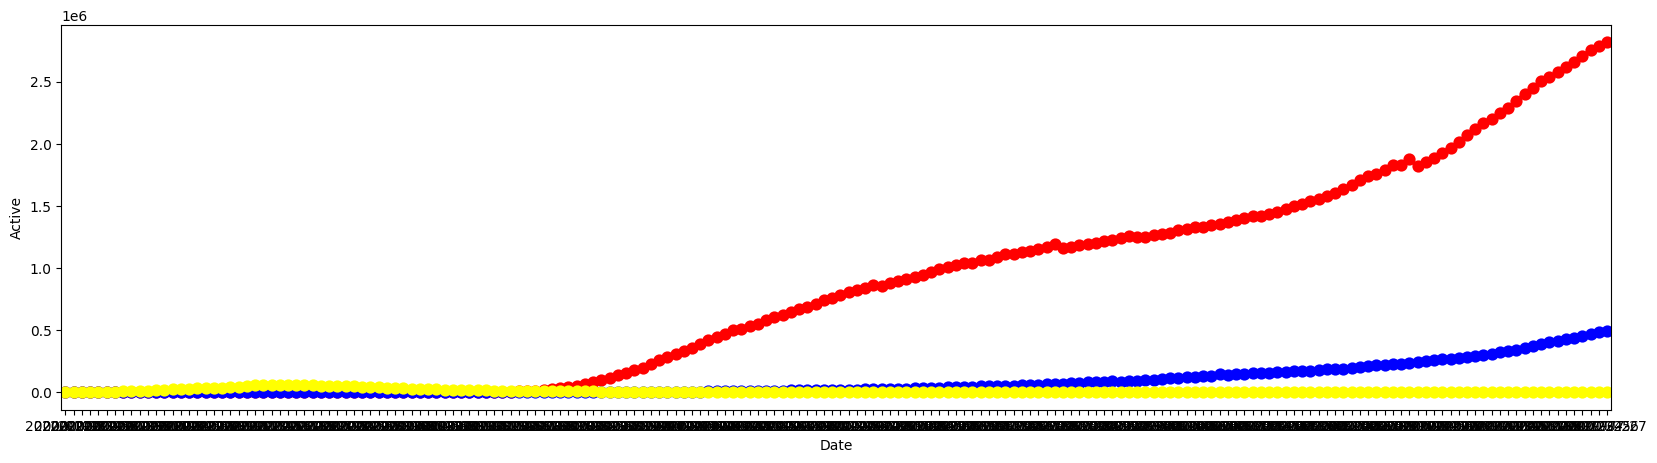

In [ ]:
plt.figure(figsize=(20,5))
sns.pointplot(data=Us,x='Date',y='Active',color='Red')
sns.pointplot(data=India,x='Date',y='Active',color='Blue')
sns.pointplot(data=China,x='Date',y='Active',color='Yellow')
plt.show()

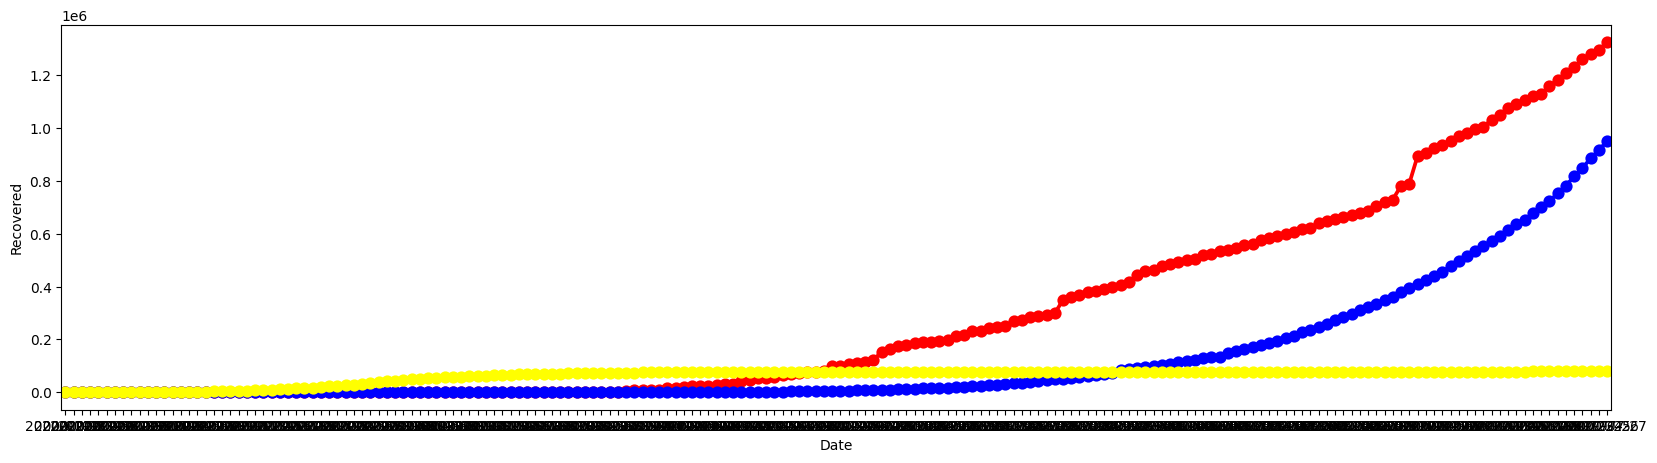

In [ ]:
plt.figure(figsize=(20,5))
sns.pointplot(data=Us,x='Date',y='Recovered',color='Red')
sns.pointplot(data=India,x='Date',y='Recovered',color='Blue')
sns.pointplot(data=China,x='Date',y='Recovered',color='Yellow')
plt.show()

#Model Building

In [ ]:
#1 Install Prophet
#2.!pip install --upgrade prophet cmdstanpy -> Upgrade prophet to make it compatible
#3. restart session, comment the above code
#4. import Prophet and create an instance

In [ ]:
'''
Prophet is a time series forecasting tool developed by Facebook that’s designed to be easy to use and effective for a wide range
of time series data. It’s particularly useful for data that has strong seasonal effects (like daily or weekly patterns) and includes
important dates or events that can impact the forecast.
'''

'\nProphet is a time series forecasting tool developed by Facebook that’s designed to be easy to use and effective for a wide range\nof time series data. It’s particularly useful for data that has strong seasonal effects (like daily or weekly patterns) and includes\nimportant dates or events that can impact the forecast.\n'

In [ ]:
#installing prophet
!pip install prophet

In [ ]:
#the column names should be "ds"->date and "y"->target, ITS MANDATORY
confirmed_cases=df.groupby(['Date']).sum()['Confirmed'].reset_index()
confirmed_cases

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [ ]:
confirmed_cases.columns=['ds','y']
confirmed_cases

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [ ]:
from prophet import Prophet

In [ ]:
model=Prophet()

In [ ]:
model.fit(confirmed_cases)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
'''
ds:
This column contains the dates for which the predictions have been made. It stands for "date stamp."

yhat:
This is the predicted value (forecast) for the given date in the ds column. It represents the model's best estimate for that point in time.

yhat_upper:
This column represents the upper bound of the predicted value, which indicates the higher end of the confidence interval.
It suggests that the actual value is unlikely to exceed this amount, giving you an idea of the prediction's uncertainty.

yhat_lower:
This column represents the lower bound of the predicted value, indicating the lower end of the confidence interval.
It suggests that the actual value is unlikely to be lower than this amount.
'''

'\nds:\nThis column contains the dates for which the predictions have been made. It stands for "date stamp."\n\nyhat:\nThis is the predicted value (forecast) for the given date in the ds column. It represents the model\'s best estimate for that point in time.\n\nyhat_upper:\nThis column represents the upper bound of the predicted value, which indicates the higher end of the confidence interval.\nIt suggests that the actual value is unlikely to exceed this amount, giving you an idea of the prediction\'s uncertainty.\n\nyhat_lower:\nThis column represents the lower bound of the predicted value, indicating the lower end of the confidence interval.\nIt suggests that the actual value is unlikely to be lower than this amount.\n'

In [ ]:
#periods = number of future rows Prophet should create beyond your original dataset

future=model.make_future_dataframe(periods=7)
forecasted=model.predict(future)
forecasted

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.613288e+03,-1.281822e+05,8.718874e+04,-9.613288e+03,-9.613288e+03,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,0.0,0.0,0.0,-2.067685e+04
1,2020-01-23,-6.933409e+03,-1.038568e+05,1.022833e+05,-6.933409e+03,-6.933409e+03,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,-8.050953e+03
2,2020-01-24,-4.253530e+03,-9.709005e+04,1.074061e+05,-4.253530e+03,-4.253530e+03,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,5.827449e+03
3,2020-01-25,-1.573651e+03,-8.916199e+04,1.115812e+05,-1.573651e+03,-1.573651e+03,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.217668e+04
4,2020-01-26,1.106228e+03,-1.030709e+05,1.169078e+05,1.106228e+03,1.106228e+03,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,8.405020e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,1.674503e+07,1.665087e+07,1.685709e+07,1.674065e+07,1.675167e+07,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,1.674392e+07
191,2020-07-31,1.694902e+07,1.685381e+07,1.706498e+07,1.694040e+07,1.696024e+07,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,1.695911e+07
192,2020-08-01,1.715301e+07,1.706335e+07,1.727082e+07,1.713788e+07,1.717261e+07,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.716677e+07
193,2020-08-02,1.735701e+07,1.724836e+07,1.747673e+07,1.733440e+07,1.738608e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.736430e+07


In [ ]:
#yhat: final forecasted value
#yhat_lower and yhat_upper: are giving a range(instead of a strict number) assuming that the future has some randomness

forecasted[['yhat_lower','yhat','yhat_upper']]

,yhat_lower,yhat,yhat_upper
0,-1.281822e+05,-2.067685e+04,8.718874e+04
1,-1.038568e+05,-8.050953e+03,1.022833e+05
2,-9.709005e+04,5.827449e+03,1.074061e+05
3,-8.916199e+04,1.217668e+04,1.115812e+05
4,-1.030709e+05,8.405020e+03,1.169078e+05
...,...,...,...
190,1.665087e+07,1.674392e+07,1.685709e+07
191,1.685381e+07,1.695911e+07,1.706498e+07
192,1.706335e+07,1.716677e+07,1.727082e+07
193,1.724836e+07,1.736430e+07,1.747673e+07


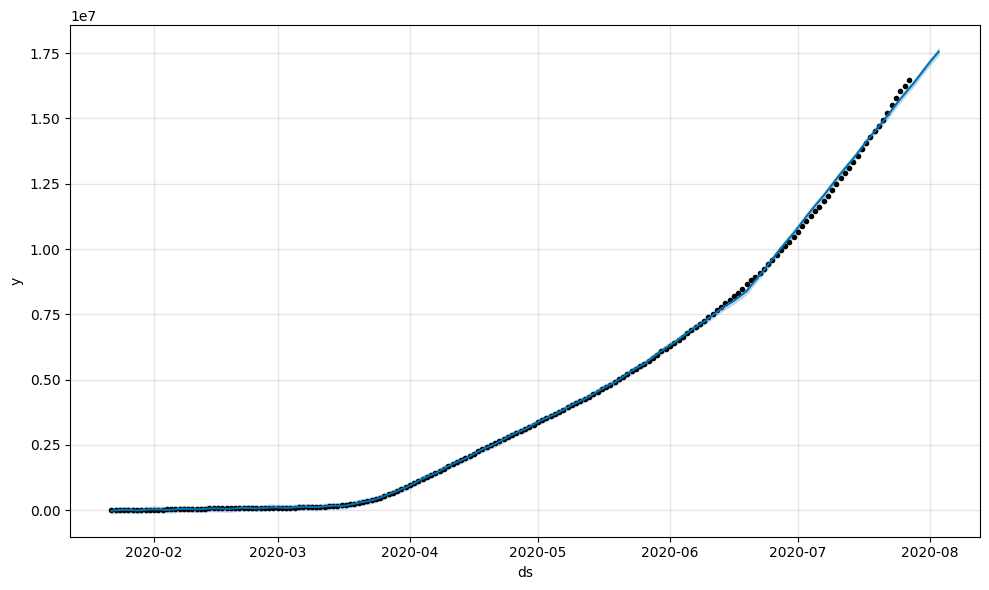

In [ ]:
model.plot(forecasted)
plt.show()

In [ ]:
recovered_cases=df.groupby(['Date']).sum()['Recovered'].reset_index()
recovered_cases

,Date,Recovered
0,2020-01-22,28
1,2020-01-23,30
2,2020-01-24,36
3,2020-01-25,39
4,2020-01-26,52
...,...,...
183,2020-07-23,8710969
184,2020-07-24,8939705
185,2020-07-25,9158743
186,2020-07-26,9293464


In [ ]:
recovered_cases.columns=['ds','y']

modelR=Prophet()

modelR.fit(recovered_cases)

future=modelR.make_future_dataframe(periods=7)
forecastedR=modelR.predict(future)
forecastedR

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-1.360144e+04,-9.500776e+04,6.105336e+04,-1.360144e+04,-1.360144e+04,-4840.633687,-4840.633687,-4840.633687,-4840.633687,-4840.633687,-4840.633687,0.0,0.0,0.0,-1.844208e+04
1,2020-01-23,-1.243662e+04,-9.062191e+04,7.218728e+04,-1.243662e+04,-1.243662e+04,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,0.0,0.0,0.0,-1.118182e+04
2,2020-01-24,-1.127180e+04,-7.640862e+04,7.533270e+04,-1.127180e+04,-1.127180e+04,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,0.0,0.0,0.0,-5.175647e+03
3,2020-01-25,-1.010697e+04,-7.902676e+04,8.097443e+04,-1.010697e+04,-1.010697e+04,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,0.0,0.0,0.0,-4.075311e+02
4,2020-01-26,-8.942151e+03,-9.203110e+04,6.563217e+04,-8.942151e+03,-8.942151e+03,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,0.0,0.0,0.0,-9.825630e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,9.594538e+06,9.515345e+06,9.682951e+06,9.590442e+06,9.598913e+06,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,0.0,0.0,0.0,9.595793e+06
191,2020-07-31,9.731096e+06,9.655616e+06,9.817401e+06,9.722250e+06,9.739204e+06,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,0.0,0.0,0.0,9.737193e+06
192,2020-08-01,9.867654e+06,9.792345e+06,9.957149e+06,9.854058e+06,9.880754e+06,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,0.0,0.0,0.0,9.877354e+06
193,2020-08-02,1.000421e+07,9.914106e+06,1.008741e+07,9.984321e+06,1.002249e+07,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,0.0,0.0,0.0,1.000333e+07


In [ ]:
Death_cases=df.groupby(['Date']).sum()['Deaths'].reset_index()
Death_cases

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


In [ ]:
Death_cases.columns=['ds','y']

modelD=Prophet()

modelD.fit(Death_cases)

future=modelD.make_future_dataframe(periods=7)
forecastedD=modelD.predict(future)
forecastedD

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-522.113185,-2682.532712,1193.751985,-522.113185,-522.113185,-191.187755,-191.187755,-191.187755,-191.187755,-191.187755,-191.187755,0.0,0.0,0.0,-713.300939
1,2020-01-23,-432.419342,-2090.749740,1909.349583,-432.419342,-432.419342,388.672065,388.672065,388.672065,388.672065,388.672065,388.672065,0.0,0.0,0.0,-43.747277
2,2020-01-24,-342.725499,-1428.696931,2450.359203,-342.725499,-342.725499,874.264079,874.264079,874.264079,874.264079,874.264079,874.264079,0.0,0.0,0.0,531.538580
3,2020-01-25,-253.031656,-1559.456736,2417.676175,-253.031656,-253.031656,726.889465,726.889465,726.889465,726.889465,726.889465,726.889465,0.0,0.0,0.0,473.857809
4,2020-01-26,-163.337813,-2329.873546,1615.654539,-163.337813,-163.337813,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,0.0,0.0,0.0,-328.938272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,663102.734264,661198.016699,665499.080440,662827.716860,663296.829945,388.672065,388.672065,388.672065,388.672065,388.672065,388.672065,0.0,0.0,0.0,663491.406328
191,2020-07-31,668132.143204,666811.126388,671123.330502,667588.844619,668605.417779,874.264079,874.264079,874.264079,874.264079,874.264079,874.264079,0.0,0.0,0.0,669006.407283
192,2020-08-01,673161.552144,671517.297682,676212.049644,672171.160925,673961.465802,726.889465,726.889465,726.889465,726.889465,726.889465,726.889465,0.0,0.0,0.0,673888.441609
193,2020-08-02,678190.961084,675367.603746,680589.737657,676702.369841,679479.106711,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,0.0,0.0,0.0,678025.360624


In [ ]:
Active_cases=df.groupby(['Date']).sum()['Active'].reset_index()
Active_cases

,Date,Active
0,2020-01-22,510
1,2020-01-23,606
2,2020-01-24,879
3,2020-01-25,1353
4,2020-01-26,2010
...,...,...
183,2020-07-23,6166006
184,2020-07-24,6212290
185,2020-07-25,6243930
186,2020-07-26,6309711


In [ ]:
Active_cases.columns=['ds','y']

modelA=Prophet()

modelA.fit(Active_cases)

future=modelA.make_future_dataframe(periods=7)
forecastedA=modelA.predict(future)
forecastedA

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-5.051891e+02,-4.900794e+04,3.699310e+04,-5.051891e+02,-5.051891e+02,-5734.815309,-5734.815309,-5734.815309,-5734.815309,-5734.815309,-5734.815309,0.0,0.0,0.0,-6.240004e+03
1,2020-01-23,1.357197e+03,-4.653318e+04,4.577238e+04,1.357197e+03,1.357197e+03,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,0.0,0.0,0.0,-1.186218e+03
2,2020-01-24,3.219584e+03,-3.849255e+04,5.267347e+04,3.219584e+03,3.219584e+03,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,0.0,0.0,0.0,6.450369e+03
3,2020-01-25,5.081970e+03,-3.813521e+04,5.346395e+04,5.081970e+03,5.081970e+03,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,0.0,0.0,0.0,8.209977e+03
4,2020-01-26,6.944356e+03,-2.820599e+04,6.539950e+04,6.944356e+03,6.944356e+03,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,0.0,0.0,0.0,1.509627e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,6.483822e+06,6.434736e+06,6.525662e+06,6.480933e+06,6.486861e+06,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,0.0,0.0,0.0,6.481279e+06
191,2020-07-31,6.546090e+06,6.502336e+06,6.597598e+06,6.540456e+06,6.553103e+06,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,0.0,0.0,0.0,6.549320e+06
192,2020-08-01,6.608357e+06,6.564823e+06,6.659315e+06,6.598968e+06,6.618568e+06,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,0.0,0.0,0.0,6.611485e+06
193,2020-08-02,6.670624e+06,6.626602e+06,6.726197e+06,6.657665e+06,6.684142e+06,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,0.0,0.0,0.0,6.678776e+06


In [ ]:
import plotly

In [ ]:
import plotly.express as px

In [ ]:
world= df.groupby(['Country'])[['Confirmed','Active','Deaths','Recovered']].sum().reset_index()
world

,Country,Confirmed,Active,Deaths,Recovered
0,Afghanistan,1936390,1089052,49098,798240
1,Albania,196702,72117,5708,118877
2,Algeria,1179755,345886,77972,755897
3,Andorra,94404,19907,5423,69074
4,Angola,22662,15011,1078,6573
...,...,...,...,...,...
182,West Bank and Gaza,233461,170967,1370,61124
183,Western Sahara,901,190,63,648
184,Yemen,67180,25694,17707,23779
185,Zambia,129421,43167,2643,83611


In [ ]:
figure=px.choropleth(world, locations='Country', locationmode='country names', color='Active', hover_name='Country', range_color=[1,100000], color_continuous_scale='reds', title='World Map for the Active Covid Cases')
figure.show()